# 第三节 从零构建感知机实现手写数字二分类

## 实验目标
通过本案例的学习：

1. 了解传统编程方法与机器学习方法的本质区别；
2. 理解感知机模型的数学表达；
3. 掌握梯度下降公式的手工推导方法。


## 注意事项

1. 本案例推荐使用Pytorch-1.0.0、CPU运行；

2. 如果您是第一次使用 JupyterLab，请查看[《ModelArts JupyterLab使用指导》](https://support.huaweicloud.com/devtool-modelarts/devtool-modelarts_0012.html)了解使用方法；

3. 如果您在使用 JupyterLab 过程中碰到报错，请参考[《ModelArts JupyterLab常见问题解决办法》](https://support.huaweicloud.com/modelarts_faq/modelarts_05_0185.html)尝试解决问题。

## 实验步骤

### 案例内容介绍
上一节，我们已经使用“统计非零像素占比，比较阈值” 这种基于图像分析的传统编程方法实现了手写数字0和1的二分类，它是一个很简单的实现策略。本节我们开始采用机器学习的方法来实现。  
有很多种机器学习方法可以实现二分类问题，本节打算先尝试采用机器学习中很简单的感知机模型，来试试分类效果如何。  
感知机模型的诞生是受到了人脑神经元的启发，如下图所示是单个人脑神经元的结构，每个神经元都与其他神经元进行相连，当神经元“兴奋”时，就会向相连的神经元传递化学物质，另一个神经元就是从树突接收其他神经元的化学物质输入，化学物质会改变轴突上的电位，当电位大于一定阈值时，这个神经元也被激活到了“兴奋”状态，也通过轴突末梢向其他神经元传递化学物质。  
![神经元](https://modelarts-labs-bj4.obs.cn-north-4.myhuaweicloud.com:443/course/hwc_edu/deep_learning/datasets/imgs/神经元.jpg)  
感知机模型的结构与神经元类似，如下图所示，它有一个输入层和输出层，输入层就相当于神经元的树突，用于接收输入，输出层就相当于轴突和轴突末梢，用于累计输入并判断是否激活至“兴奋状态”。  
![感知机](https://modelarts-labs-bj4.obs.cn-north-4.myhuaweicloud.com:443/course/hwc_edu/deep_learning/datasets/imgs/感知机.jpg)  
感知机可以使用的激活函数有很多种，上图中使用的是sigmoid函数，它的函数曲线如下图所示，可以看出函数的取值区间是(0.0, 1.0)。  
![sigmoid函数曲线](https://modelarts-labs-bj4.obs.cn-north-4.myhuaweicloud.com:443/course/hwc_edu/deep_learning/datasets/imgs/sigmoid函数曲线.jpg)   
那么，我们如何使用感知机来实现手写数字0和1的二分类呢？
我们已知手写数字图片的数据可以用28\*28的数组来表示，那么可以将这个数组转换为784\*1的列向量，这个列向量作为感知机的输入，也就是说输入和权值都是784个。  
感知机的输出是0.0到1.0之前的小数，而我们需要的是二分类问题，期望最终输出的结果是0或1。因为我们可以在得到感知机的输出y之后，再加一个后处理判断，如果y>0.5，则判为类别1，否则判为类别0，这就是采用感知机来实现手写数字0和1二分类的方法，可以表示为下图：   
![感知机实现二分类](https://modelarts-labs-bj4.obs.cn-north-4.myhuaweicloud.com:443/course/hwc_edu/deep_learning/datasets/imgs/感知机实现二分类.jpg) 

### 1. 传统编程方法与机器学习方法的本质区别
用感知机来实现二分类的可行性已经得到验证了，在开始具体的实现之前，我们先来理解传统编程方法与机器学习方法之间的区别。  

#### 传统编程方法的模式
传统编程方法的模式可以用下图来表示，大多数程序都可以看成是一个盒子，给定明确的输入，得到明确的输出，而且这个程序的实现逻辑都是由程序员一行行编写出来的，人告诉计算机一步步怎么做，人完全能解释为什么给某个输入能得到某个输出。  
![传统编程方法的模式](https://modelarts-labs-bj4.obs.cn-north-4.myhuaweicloud.com:443/course/hwc_edu/deep_learning/datasets/imgs/传统编程方法的模式.jpg)

#### 机器学习方法的模式
机器学习方法的模式可以用下图来表示，核心在于“网络结构 + 参数”，也可以把它看成一个特殊的程序，只不过这个程序不是由程序员编写出来的，人只定义了网络结构，而参数是由计算机通过机器学习方法“学习”得来的，人无法解释为什么要取这些参数值。  
![机器学习方法的模式](https://modelarts-labs-bj4.obs.cn-north-4.myhuaweicloud.com:443/course/hwc_edu/deep_learning/datasets/imgs/机器学习方法的模式.jpg)

#### 机器学习方法的学习模式
那么机器学习方法是如何“学习”的呢？思想其实很简单，可以用下图来表示:  
![机器学习方法的学习模式](https://modelarts-labs-bj4.obs.cn-north-4.myhuaweicloud.com:443/course/hwc_edu/deep_learning/datasets/imgs/机器学习方法的学习模式.jpg)

上图的学习模式可以归纳为以下几点：  
（1）定义网络结构，并给网络中的所有参数 w 赋予随机值；  
（2）使用网络对一批样本进行预测，得到预测值pred_y；  
（3）定义一个损失函数，如 $loss=(pred\_y-true\_y)^2$，true_y是指标签，模型训练的目的就是使得所有训练数据的损失之和尽可能地小；  
（4）求得损失函数对所有参数的梯度 gradient_w；  
（5）按照公式 w = w - lr * gradient_w 对所有参数w进行更新，其中lr是指学习率，常见的取值有0.01、0.001、0.0001等。  

下面我们将按照以上归纳的几点来实现整个机器学习过程，现在不理解这几点没关系，等完成所有代码实现之后，再来回顾理解。

### 2. 加载数据集
开始实现机器学习过程之前，仍然是要先加载数据集。由于整个MNIST数据集是包含0~9的所有图片，我们现在研究的是简化的0和1的二分类问题，所以先从整个数据集中将所有手写数字0和1的图片挑选出来，同样也需要区分训练集和测试集。  

挑选数字0和1的训练样本和测试样本

In [1]:
import os
import numpy as np
import torchvision.datasets.mnist as mnist

datasets_dir = '../datasets'
if not os.path.exists(datasets_dir):
    os.makedirs(datasets_dir)
import moxing as mox
if not os.path.exists(os.path.join(datasets_dir, 'MNIST_data.zip')):
    mox.file.copy('obs://modelarts-labs-bj4/course/hwc_edu/deep_learning/datasets/MNIST_data.zip', 
                  os.path.join(datasets_dir, 'MNIST_data.zip'))
    os.system('cd %s; unzip MNIST_data.zip' % (datasets_dir))

# 读取完整训练样本
train_data = mnist.read_image_file(os.path.join(datasets_dir, 'MNIST_data/raw/train-images-idx3-ubyte')).numpy().astype(np.uint8)
train_label = mnist.read_label_file(os.path.join(datasets_dir, 'MNIST_data/raw/train-labels-idx1-ubyte')).numpy().astype(np.uint8)
# 读取完整测试样本
test_data = mnist.read_image_file(os.path.join(datasets_dir, 'MNIST_data/raw/t10k-images-idx3-ubyte')).numpy().astype(np.uint8)
test_label = mnist.read_label_file(os.path.join(datasets_dir, 'MNIST_data/raw/t10k-labels-idx1-ubyte')).numpy().astype(np.uint8)

train_zeros = train_data[train_label == 0]
train_ones = train_data[train_label == 1]
test_zeros = test_data[test_label == 0]
test_ones = test_data[test_label == 1]

print('数字0，训练集规模：', len(train_zeros), '，测试集规模：', len(test_zeros))
print('数字1，训练集规模：', len(train_ones), '，测试集规模：', len(test_ones))

INFO:root:Using MoXing-v1.17.3-

INFO:root:Using OBS-Python-SDK-3.20.7


数字0，训练集规模： 5923 ，测试集规模： 980

数字1，训练集规模： 6742 ，测试集规模： 1135


将数字0和1的样本进行汇总

In [2]:
train_x = np.vstack((train_zeros, train_ones))  # 将数字0和1的样本汇总起来，np.vstack表示将两个数组进行垂直拼接
train_y = np.array([0] * len(train_zeros) + [1] * len(train_ones)).astype(np.uint8)

test_x = np.vstack((test_zeros, test_ones))  # 将数字0和1的样本汇总起来，np.vstack表示将两个数组进行垂直拼接
test_y = np.array([0] * len(test_zeros) + [1] * len(test_ones)).astype(np.uint8)

In [3]:
train_x = train_x.reshape(-1, 28*28)  # 每个样本变成一个行向量，因为行向量便于计算
train_y = train_y.reshape(-1, 1)

test_x = test_x.reshape(-1, 28*28)  # 每个样本变成一个行向量，因为行向量便于计算
test_y = test_y.reshape(-1, 1)

In [4]:
print(train_x.shape, train_y.shape, test_x.shape, test_y.shape)

(12665, 784) (12665, 1) (2115, 784) (2115, 1)


### 3. 混洗数据集
因为机器学习的方法是通过训练样本的训练来获取一个具备分类能力的模型，并且这个模型会更倾向于“记住”最后一批训练样本。如果你给模型的训练数据的前一段全是数字0，后一段全是数字1，那么该模型最终就会倾向于更擅长分类数字1。因此，如果要使模型获得较平衡的分类能力，我们需要将训练数据打乱顺序。  
测试集仅用于测试，不参与训练，不强制进行混洗，是一个可选的操作。

In [5]:
train_data = np.hstack((train_x, train_y))  # np.hstack表示将两个数组进行水平拼接
test_data = np.hstack((test_x, test_y))  # np.hstack表示将两个数组进行水平拼接
np.random.seed(0)
np.random.shuffle(train_data)  # 打乱train_data数组的行顺序
np.random.shuffle(test_data)  # 打乱test_data数组的行顺序
train_x = train_data[:, :-1]  # 重新取出train_x和train_y
train_y = train_data[:, -1].reshape(-1, 1)
test_x = test_data[:, :-1]  # 重新取出train_x和train_y
test_y = test_data[:, -1].reshape(-1, 1)

查看图片及标签是否已被打乱

In [6]:
from PIL import Image
batch_size = 10  # 查看10个样本
print(train_y.flatten()[:batch_size].tolist())
batch_img = train_x[0].reshape(28, 28)
for i in range(1, batch_size):
    batch_img = np.hstack((batch_img, train_x[i].reshape(28, 28)))  # 将一批图片水平拼接起来，方便下一步进行显示
Image.fromarray(batch_img)

[1, 0, 0, 1, 0, 0, 1, 1, 0, 0]


### 4. 数据预处理
大多数机器学习的方法都要先将数据进行预处理再进行学习，预处理的方法有很多种，本案例只对数据进行归一化预处理。  
归一化就是指将训练数据的取值范围变成[0, 1]。数据归一化有很多的好处，既可以使学习过程更快，也可以防止某些情况下训练过程出现计算溢出。  
图像数据有很多种归一化方式，本案例采用的是整个数组除以255的方式，因为图像数组的最大值是255，除以255就可以使图像数据的取值范围变成[0, 1]。

In [7]:
train_x = train_x.astype(np.float) / 255.0
train_y = train_y.astype(np.float)

test_x = test_x.astype(np.float) / 255.0
test_y = test_y.astype(np.float)

### 5. 封装成load_data函数
到此，我们就完成了训练数据的准备工作，可以将以上操作封装成load_data函数，以便后面再次用到

In [8]:
%%writefile ../datasets/MNIST_data/load_data_zeros_ones.py
def load_data_zeros_ones(datasets_dir):
    import os
    import numpy as np
    import torchvision.datasets.mnist as mnist

    datasets_dir = '../datasets'
    if not os.path.exists(datasets_dir):
        os.makedirs(datasets_dir)
    import moxing as mox
    if not os.path.exists(os.path.join(datasets_dir, 'MNIST_data.zip')):
        mox.file.copy('obs://modelarts-labs-bj4/course/hwc_edu/deep_learning/datasets/MNIST_data.zip', 
                      os.path.join(datasets_dir, 'MNIST_data.zip'))
        os.system('cd %s; unzip MNIST_data.zip' % (datasets_dir))
    
    # 读取完整训练样本
    train_data = mnist.read_image_file(os.path.join(datasets_dir, 'MNIST_data/raw/train-images-idx3-ubyte')).numpy().astype(np.uint8)
    train_label = mnist.read_label_file(os.path.join(datasets_dir, 'MNIST_data/raw/train-labels-idx1-ubyte')).numpy().astype(np.uint8)
    # 读取完整测试样本
    test_data = mnist.read_image_file(os.path.join(datasets_dir, 'MNIST_data/raw/t10k-images-idx3-ubyte')).numpy().astype(np.uint8)
    test_label = mnist.read_label_file(os.path.join(datasets_dir, 'MNIST_data/raw/t10k-labels-idx1-ubyte')).numpy().astype(np.uint8)

    train_zeros = train_data[train_label == 0]
    train_ones = train_data[train_label == 1]
    test_zeros = test_data[test_label == 0]
    test_ones = test_data[test_label == 1]

    print('数字0，训练集规模：', len(train_zeros), '，测试集规模：', len(test_zeros))
    print('数字1，训练集规模：', len(train_ones), '，测试集规模：', len(test_ones))
    
    train_x = np.vstack((train_zeros, train_ones))  # 将数字0和1的样本汇总起来，np.vstack表示将两个数组进行垂直拼接
    train_y = np.array([0] * len(train_zeros) + [1] * len(train_ones)).astype(np.uint8)

    test_x = np.vstack((test_zeros, test_ones))  # 将数字0和1的样本汇总起来，np.vstack表示将两个数组进行垂直拼接
    test_y = np.array([0] * len(test_zeros) + [1] * len(test_ones)).astype(np.uint8)
    
    train_x = train_x.reshape(-1, 28*28)  # 每个样本变成一个行向量，因为行向量便于计算
    train_y = train_y.reshape(-1, 1)

    test_x = test_x.reshape(-1, 28*28)  # 每个样本变成一个行向量，因为行向量便于计算
    test_y = test_y.reshape(-1, 1)
    
    train_data = np.hstack((train_x, train_y))  # np.hstack表示将两个数组进行水平拼接
    test_data = np.hstack((test_x, test_y))  # np.hstack表示将两个数组进行水平拼接
    np.random.seed(0)
    np.random.shuffle(train_data)  # 打乱train_data数组的行顺序
    np.random.shuffle(test_data)  # 打乱test_data数组的行顺序
    train_x = train_data[:, :-1]  # 重新取出train_x和train_y
    train_y = train_data[:, -1].reshape(-1, 1)
    test_x = test_data[:, :-1]  # 重新取出train_x和train_y
    test_y = test_data[:, -1].reshape(-1, 1)
    
    train_x = train_x.astype(np.float) / 255.0
    train_y = train_y.astype(np.float)

    test_x = test_x.astype(np.float) / 255.0
    test_y = test_y.astype(np.float)

    return train_x, train_y, test_x, test_y

Overwriting ../datasets/MNIST_data/load_data_zeros_ones.py


### 6. 定义网络结构
![感知机](https://modelarts-labs-bj4.obs.cn-north-4.myhuaweicloud.com:443/course/hwc_edu/deep_learning/datasets/imgs/感知机.jpg)  
本案例的网络采用如上图所示的感知机结构，除去输入X和输出y之外，图中的权值W、阈值b、加权求和函数单元、非线性函数单元都需要定义，可以通过下面的代码来实现网络结构的定义  

In [9]:
np.random.seed(0)

In [10]:
class Network(object):
    def __init__(self, num_of_weights):
        self.w = np.random.randn(num_of_weights, 1)  # 使用np.random.randn随机生成一个 num_of_weights*1 的列向量，该向量即为权值w
        self.b = 0.
    
    def forward(self, x):  # 加权求和单元和非线性函数单元通过定义计算过程来实现
        z = np.dot(x, self.w) + self.b  # 加权求和
        pred_y = 1.0 / (1.0 + np.exp(-z))  # 非线性函数sigmoid
        return pred_y

我们随机初始化两个网络，并对同一个样本进行预测

In [11]:
net1 = Network(28*28)
sample = train_x[0]
true_y = train_y[0]
pred_y_1 = net1.forward(sample)
print('true_y:', true_y, 'pred_y:', pred_y_1)

true_y: [1.] pred_y: [6.12431635e-05]


In [12]:
net2 = Network(28*28)
sample = train_x[0]
true_y = train_y[0]
pred_y_2 = net2.forward(sample)
print('true_y:', true_y, 'pred_y:', pred_y_2)

true_y: [1.] pred_y: [0.99999943]


### 7. 定义损失函数

上面的两个网络对同一个标签为1的样本进行了预测，net1的预测值是0.00006124，net2的预测值是0.99999943，显然net2的预测值更接近真实值，我们可以做出评价：net2对train_x[0]这个样本的预测效果比net1更好。  
我们要设计出一个能自我学习、自我改进的网络，我们就得告诉计算机当前这个网络到底好不好，并且要有一个量化的指标来衡量“好”或“不好”的程度，这个量化的指标在机器学习当中就称为损失值loss。  
计算loss有很多种方法，常用的一种方法就是均方误差，计算公式如下：  
$loss=(pred\_y-true\_y)^2$

于是，我们可以计算上面net1和net2两个网络在train_x[0]这个样本上的损失值，可以看到loss2比loss1小

In [13]:
loss1 = (pred_y_1 - true_y)**2
loss2 = (pred_y_2 - true_y)**2
print('loss1:', loss1, 'loss2:', loss2)

loss1: [0.99987752] loss2: [3.22665012e-13]


但是，我们评价某个网络好不好，不是在单个样本上进行评价，而是要在一批样本上进行评价，所以就要计算一批样本的损失值。我们对上面单个样本的损失值计算公式进行改进，就可以得到一批样本的损失值计算公式，具体如下：
$
loss=\frac{1}{N}\sum^{N}_{i=0}{(pred\_y-true\_y)^2}
$

于是，我们可以使用如下代码来定义网络的损失函数

In [14]:
class Network(object):
    def __init__(self, num_of_weights):
        np.random.seed(0)
        self.w = np.random.randn(num_of_weights, 1)  # 使用np.random.randn随机生成一个 num_of_weights*1 的列向量，该向量即为权值W
        self.b = 0.
    
    def forward(self, x):  # 加权求和单元和非线性函数单元通过定义计算过程来实现
        z = np.dot(x, self.w) + self.b  # 加权求和
        pred_y = 1.0 / (1.0 + np.exp(-z))  # 非线性函数sigmoid
        return pred_y

    def loss_fun(self, pred_y, true_y):
        """
        pred_y：网络对一批样本的预测值组成的列向量
        true_y：一批样本的真实标签
        """
        error = pred_y - true_y
        num_samples = error.shape[0]
        cost = error * error
        cost = np.sum(cost) / num_samples
        return cost

下面我们可以计算十个样本的总体损失值

In [15]:
net3 = Network(28*28)
sample = train_x[0:10]
true_y = train_y[0:10]
pred_y = net3.forward(sample)
print('loss:', net3.loss_fun(pred_y, true_y))

loss: 0.4621188993657137


### 8. 定义评价函数
定义好损失函数之后，我们还要定义评价函数。这两个函数都是用来评估模型的表现，很多人会混淆它们的含义，下面来解释两者的区别：  
（1）损失函数是用于衡量模型的预测值和真实值之间的偏差，偏差越大，梯度就越大，对参数更新的幅度就越大，整个机器学习过程的目标就是是损失函数的值尽可能地小；  
（2）评价函数有多种评价指标，常用的指标是准确率，它是用于统计模型预测结果的正确率，比如有100个测试样本，其中有99个都预测正确了，准确率就是99%；

言而简之，损失函数是作用于梯度下降过程的，评价函数是统计模型的评价指标给人看的。

In [16]:
class Network(object):
    def __init__(self, num_of_weights):
        np.random.seed(0)
        self.w = np.random.randn(num_of_weights, 1)  # 使用np.random.randn随机生成一个 num_of_weights*1 的列向量，该向量即为权值W
        self.b = 0.
    
    def forward(self, x):  # 加权求和单元和非线性函数单元通过定义计算过程来实现
        z = np.dot(x, self.w) + self.b  # 加权求和
        pred_y = 1.0 / (1.0 + np.exp(-z))  # 非线性函数sigmoid
        return pred_y

    def loss_fun(self, pred_y, true_y):
        """
        pred_y：网络对一批样本的预测值组成的列向量
        true_y：一批样本的真实标签
        """
        error = pred_y - true_y
        num_samples = error.shape[0]
        cost = error * error
        cost = np.sum(cost) / num_samples
        return cost
    
    def evaluate(self, pred_y, true_y, threshold=0.5):
        pred_y[pred_y < threshold] = 0  # 预测值小于0.5，则判为类别0
        pred_y[pred_y >= threshold] = 1

        acc = (pred_y == true_y).float().mean()
        return acc

### 9. 手工推导实现梯度下降算法
实现梯度下降算法就是两个步骤：  
（1）求得损失函数对所有参数的梯度 gradient_w；  
（2）按照公式 w = w - lr * gradient_w 对所有参数w进行更新  

关键的步骤在第一步，如果需从零实现损失函数对所有参数的梯度计算方法，则需要一定的数学基础进行公式推导，对此过程感兴趣的话，可以查看博文[《手工推导梯度下降公式》](https://bbs.huaweicloud.com/blogs/255905)。如果不关注公式的推导过程，可以直接查看下面代码中的 gradient 函数。  
第二步的实现很简单，见下面代码中的 update 函数。

In [17]:
class Network(object):
    def __init__(self, num_of_weights):
        np.random.seed(0)
        self.w = np.random.randn(num_of_weights, 1)  # 使用np.random.randn随机生成一个 num_of_weights*1 的列向量，该向量即为权值W
        self.b = 0.
    
    def forward(self, x):  # 加权求和单元和非线性函数单元通过定义计算过程来实现
        z = np.dot(x, self.w) + self.b  # 加权求和
        pred_y = 1.0 / (1.0 + np.exp(-z))  # 非线性函数sigmoid
        return pred_y

    def loss_fun(self, pred_y, true_y):
        """
        pred_y：网络对一批样本的预测值组成的列向量
        true_y：一批样本的真实标签
        """
        error = pred_y - true_y
        num_samples = error.shape[0]
        cost = error * error
        cost = np.sum(cost) / num_samples
        return cost
    
    def evaluate(self, pred_y, true_y, threshold=0.5):
        pred_y[pred_y < threshold] = 0  # 预测值小于0.5，则判为类别0
        pred_y[pred_y >= threshold] = 1

        acc = (pred_y == true_y).float().mean()
        return acc
    
    def gradient(self, x, y, pred_y):
        gradient_w = (pred_y-y)*pred_y*(1-pred_y)*x
        gradient_w = np.mean(gradient_w, axis=0)
        gradient_w = gradient_w[:, np.newaxis]
        gradient_b = (pred_y - y)*pred_y*(1-pred_y)
        gradient_b = np.mean(gradient_b)        
        return gradient_w, gradient_b
    
    def update(self, gradient_w, gradient_b, eta = 0.01):
        self.w = self.w - eta * gradient_w
        self.b = self.b - eta * gradient_b

### 10. 实现训练函数
![机器学习方法的学习模式](https://modelarts-labs-bj4.obs.cn-north-4.myhuaweicloud.com:443/course/hwc_edu/deep_learning/datasets/imgs/机器学习方法的学习模式.jpg)  
训练函数的过程，就是把上图中的2、3、4、5点子过程串起来，详情请查看下面代码中的 train 函数 

In [18]:
class Network(object):
    def __init__(self, num_of_weights):
        np.random.seed(0)
        self.w = np.random.randn(num_of_weights, 1)  # 使用np.random.randn随机生成一个 num_of_weights*1 的列向量，该向量即为权值W
        self.b = 0.
    
    def forward(self, x):  # 加权求和单元和非线性函数单元通过定义计算过程来实现
        z = np.dot(x, self.w) + self.b  # 加权求和
        pred_y = 1.0 / (1.0 + np.exp(-z))  # 非线性函数sigmoid
        return pred_y

    def loss_fun(self, pred_y, true_y):
        """
        pred_y：网络对一批样本的预测值组成的列向量
        true_y：一批样本的真实标签
        """
        error = pred_y - true_y
        num_samples = error.shape[0]
        cost = error * error
        cost = np.sum(cost) / num_samples
        return cost
    
    def evaluate(self, pred_y, true_y, threshold=0.5):
        pred_y[pred_y < threshold] = 0  # 预测值小于0.5，则判为类别0
        pred_y[pred_y >= threshold] = 1

        acc = np.mean((pred_y == true_y).astype(np.float))
        return acc
    
    def gradient(self, x, y, pred_y):
        gradient_w = (pred_y-y)*pred_y*(1-pred_y)*x
        gradient_w = np.mean(gradient_w, axis=0)
        gradient_w = gradient_w[:, np.newaxis]
        gradient_b = (pred_y - y)*pred_y*(1-pred_y)
        gradient_b = np.mean(gradient_b)        
        return gradient_w, gradient_b
    
    def update(self, gradient_w, gradient_b, lr = 0.01):
        self.w = self.w - lr * gradient_w
        self.b = self.b - lr * gradient_b
    
    def train(self, train_x, train_y, test_x, test_y, max_epochs=100, lr=0.01):
        train_losses = []
        test_losses = []
        train_accs = []
        test_accs = []
        for epoch in range(1, max_epochs + 1):
            pred_y_train = self.forward(train_x)
            gradient_w, gradient_b = self.gradient(train_x, train_y, pred_y_train)
            self.update(gradient_w, gradient_b, lr)              
            if (epoch == 1) or (epoch % 200 == 0):
                pred_y_test = self.forward(test_x)
                train_loss = self.loss_fun(pred_y_train, train_y)
                test_loss = self.loss_fun(pred_y_test, test_y)
                train_acc = self.evaluate(pred_y_train, train_y)
                test_acc = self.evaluate(pred_y_test, test_y)
                print('epoch: %d, train_loss: %.4f, test_loss: %.4f, train_acc: %.4f, test_acc: %.4f' % (epoch, train_loss, test_loss, train_acc, test_acc))
                train_losses.append(train_loss)
                test_losses.append(test_loss)
                train_accs.append(train_acc)
                test_accs.append(test_acc)
        return train_losses, test_losses, train_accs, test_accs

### 11. 开始训练
CPU上训练耗时约600秒

In [19]:
import time
start_time = time.time()
# 创建网络
net = Network(28*28)
max_epochs = 3000
# 启动训练
train_losses, test_losses, train_accs, test_accs = net.train(train_x, train_y, test_x, test_y, max_epochs=max_epochs, lr=0.01)
print('cost time: %.1f s' % (time.time() - start_time))

epoch: 1, train_loss: 0.5107, test_loss: 0.5172, train_acc: 0.4716, test_acc: 0.4643

epoch: 200, train_loss: 0.5043, test_loss: 0.5107, train_acc: 0.4738, test_acc: 0.4671

epoch: 400, train_loss: 0.4950, test_loss: 0.5009, train_acc: 0.4797, test_acc: 0.4704

epoch: 600, train_loss: 0.4814, test_loss: 0.4863, train_acc: 0.4912, test_acc: 0.4799

epoch: 800, train_loss: 0.4617, test_loss: 0.4649, train_acc: 0.5064, test_acc: 0.5017

epoch: 1000, train_loss: 0.4341, test_loss: 0.4359, train_acc: 0.5289, test_acc: 0.5286

epoch: 1200, train_loss: 0.3982, test_loss: 0.3995, train_acc: 0.5630, test_acc: 0.5617

epoch: 1400, train_loss: 0.3543, test_loss: 0.3565, train_acc: 0.6039, test_acc: 0.6014

epoch: 1600, train_loss: 0.3036, test_loss: 0.3075, train_acc: 0.6504, test_acc: 0.6487

epoch: 1800, train_loss: 0.2499, test_loss: 0.2537, train_acc: 0.7020, test_acc: 0.6955

epoch: 2000, train_loss: 0.1998, test_loss: 0.2013, train_acc: 0.7548, test_acc: 0.7560

epoch: 2200, train_loss: 0.1

从上面的结果可以看到，使用感知机模型，训练3000个epoch之后达到了0.9073的准确率，这个二分类的准确率比上一节使用传统编程方法的0.9674的准确率还低。

### 12. 训练过程可视化
将训练过程中的train_loss, test_loss, train_acc, test_acc绘制成曲线图，分析这些指标的变化趋势

INFO:matplotlib.font_manager:font search path ['/home/ma-user/anaconda3/envs/Pytorch-1.0.0/lib/python3.6/site-packages/matplotlib/mpl-data/fonts/ttf', '/home/ma-user/anaconda3/envs/Pytorch-1.0.0/lib/python3.6/site-packages/matplotlib/mpl-data/fonts/afm', '/home/ma-user/anaconda3/envs/Pytorch-1.0.0/lib/python3.6/site-packages/matplotlib/mpl-data/fonts/pdfcorefonts']

INFO:matplotlib.font_manager:generated new fontManager


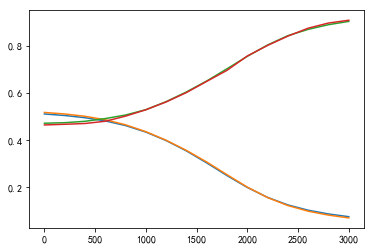

In [20]:
import matplotlib.pyplot as plt
%matplotlib inline

# 画出各指标的变化趋势
plot_x = np.arange(0, max_epochs+1, 200)
plot_y_1 = np.array(train_losses)
plot_y_2 = np.array(test_losses)
plot_y_3 = np.array(train_accs)
plot_y_4 = np.array(test_accs)
plt.plot(plot_x, plot_y_1)
plt.plot(plot_x, plot_y_2)
plt.plot(plot_x, plot_y_3)
plt.plot(plot_x, plot_y_4)
plt.show()

### 本节扩展学习材料
[神经网络基础概念](https://education.huaweicloud.com/courses/course-v1:HuaweiX+CBUCNXE088+Self-paced/courseware/2aaefc7acffd43ab8eff5cacce98998b/7fabbe3faa8e441fa91877a636f7e35d/)  
[参数初始化](https://education.huaweicloud.com/courses/course-v1:HuaweiX+CBUCNXE088+Self-paced/courseware/5b3b6cd6b90544c2b68e6e1c7caba37b/00ba45964ecc461085f6775365ff45de/)

至此，本案例完成。